จำนวนข้อมูลชุด Train: 2666 แถว
จำนวนข้อมูลชุด Test : 667 แถว

--- 📊 1. ผลการประเมินประสิทธิภาพโมเดล ---
Silhouette Score (Train): 0.0752
Silhouette Score (Test) : 0.0812

--- 📑 2. ตารางสรุปพฤติกรรมเฉลี่ยของลูกค้าแต่ละกลุ่ม ---


,Number of Customers,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
Cluster_Label,,,,,,,,,,,,,,,,,
0,725,0.11,1.00,29.35,179.78,100.17,30.56,201.56,100.11,17.13,200.36,100.38,9.02,10.17,4.53,2.75,1.54
1,925,0.11,0.00,0.00,216.66,100.03,36.83,209.31,100.49,17.79,177.71,100.58,8.00,9.80,4.39,2.65,1.48
2,495,0.09,0.00,0.00,169.37,102.14,28.79,163.97,97.85,13.94,243.87,100.80,10.97,10.99,4.50,2.97,1.72
3,521,0.06,0.00,0.00,123.28,100.46,20.96,219.10,100.83,18.62,200.12,97.22,9.01,10.39,4.40,2.81,1.65




--- 🏆 3. วิเคราะห์: 5 อันดับปัจจัยหลักที่ใช้แบ่งกลุ่มลูกค้า ---


,Feature (ตัวแปร),Importance (%)
1,Voice mail plan,20.223161
2,Number vmail messages,19.107435
5,Total day charge,13.168408
3,Total day minutes,12.715642
9,Total night minutes,8.333924


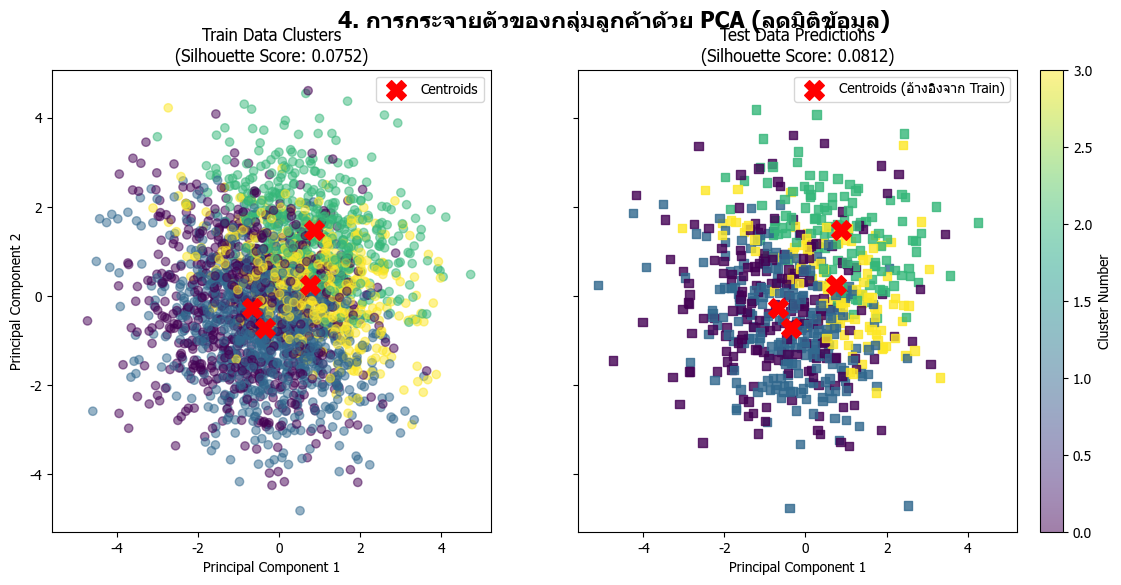

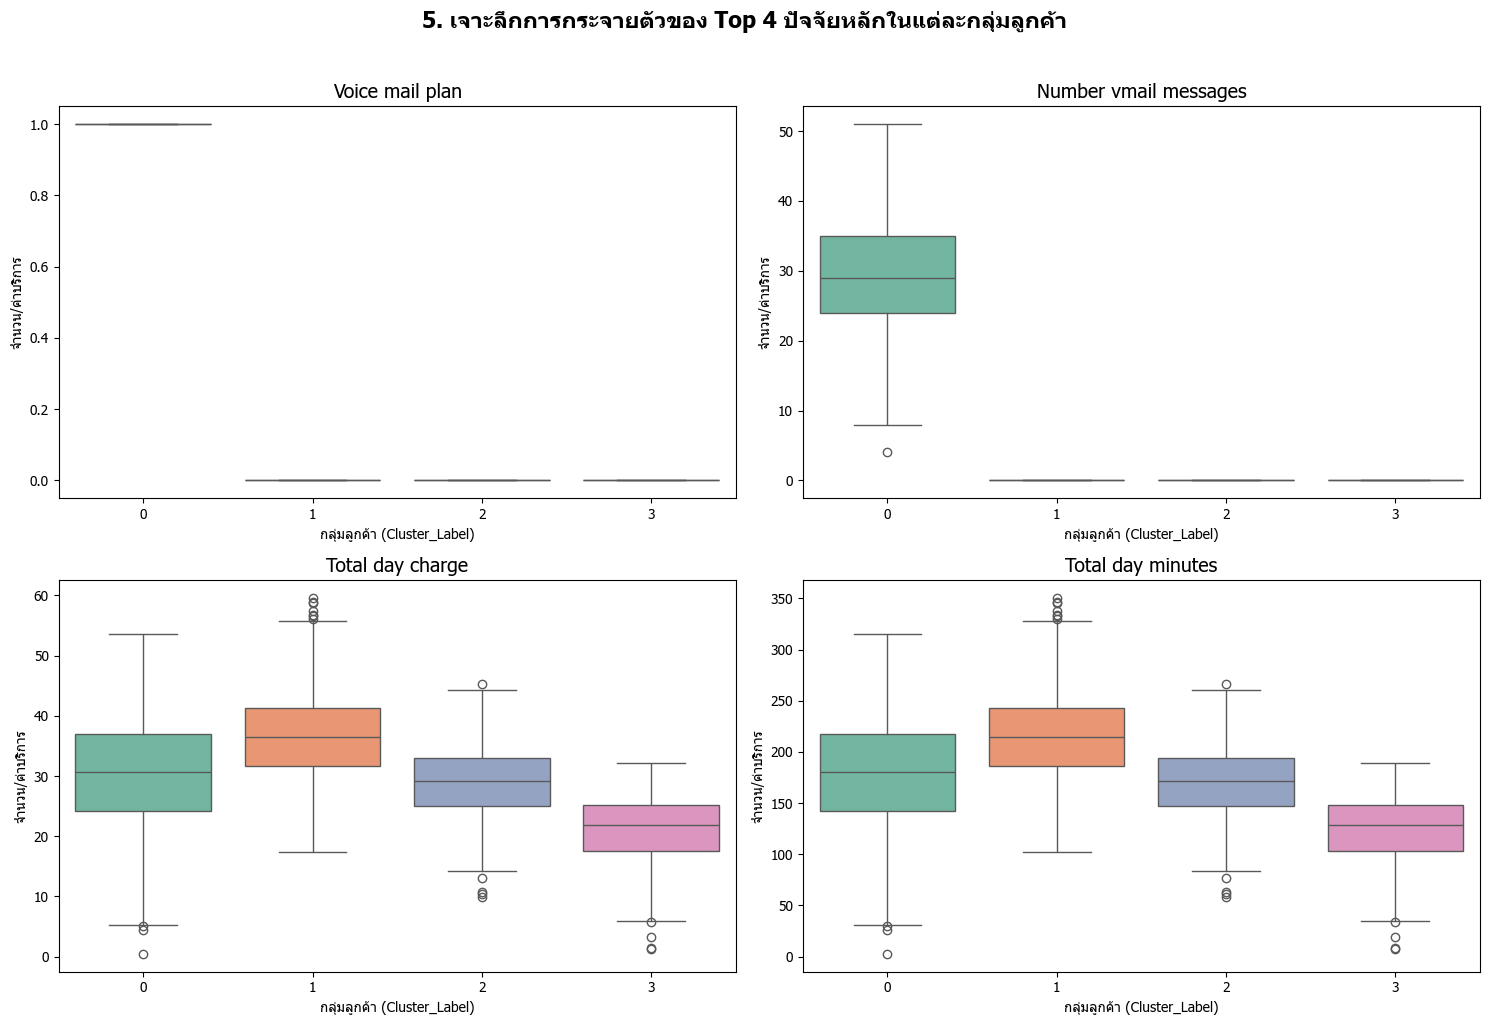

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # เพิ่ม seaborn สำหรับวาด Boxplot สวยๆ
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import BisectingKMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier # เพิ่ม Random Forest สำหรับหา Feature Importance
from IPython.display import display

# ==========================================
# 0. ตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟ
# ==========================================
plt.rcParams['font.family'] = 'Tahoma'  
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. โหลดและเตรียมข้อมูล (Data Preprocessing)
# ==========================================
df = pd.read_csv('telecom_dataset.csv') # เช็ค Path ให้ถูกต้อง

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})

features = [
    'International plan', 'Voice mail plan', 'Number vmail messages',
    'Total day minutes', 'Total day calls', 'Total day charge',
    'Total eve minutes', 'Total eve calls', 'Total eve charge',
    'Total night minutes', 'Total night calls', 'Total night charge',
    'Total intl minutes', 'Total intl calls', 'Total intl charge',
    'Customer service calls'
]
X = df[features]

# ==========================================
# 2. แบ่งข้อมูลเป็นชุด Train และ Test
# ==========================================
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"จำนวนข้อมูลชุด Train: {X_train.shape[0]} แถว")
print(f"จำนวนข้อมูลชุด Test : {X_test.shape[0]} แถว\n")

# ==========================================
# 3. Data Preprocessing (Scaling)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. สร้างโมเดลและประเมินผล (Bisecting K-Means)
# ==========================================
n_clusters = 4  
bisect_kmeans = BisectingKMeans(n_clusters=n_clusters, n_init=5, random_state=42)

train_labels = bisect_kmeans.fit_predict(X_train_scaled)
test_labels = bisect_kmeans.predict(X_test_scaled)

train_silhouette = silhouette_score(X_train_scaled, train_labels)
test_silhouette = silhouette_score(X_test_scaled, test_labels)

print("--- 📊 1. ผลการประเมินประสิทธิภาพโมเดล ---")
print(f"Silhouette Score (Train): {train_silhouette:.4f}")
print(f"Silhouette Score (Test) : {test_silhouette:.4f}\n")

# ==========================================
# 5. วิเคราะห์พฤติกรรมลูกค้าแต่ละกลุ่ม (Cluster Profiling - ฉบับจัดเต็ม)
# ==========================================
X_train_profile = X_train.copy()
X_train_profile['Cluster_Label'] = train_labels

print("--- 📑 2. ตารางสรุปพฤติกรรมเฉลี่ยของลูกค้าแต่ละกลุ่ม ---")
profile_mean = X_train_profile.groupby('Cluster_Label').mean()
cluster_counts = X_train_profile.groupby('Cluster_Label').size().rename('Number of Customers')
profile_full = pd.concat([cluster_counts, profile_mean], axis=1)

styled_profile = (
    profile_full.style
    .background_gradient(cmap='YlOrRd', subset=profile_mean.columns, axis=0) 
    .format("{:.0f}", subset=['Number of Customers']) 
    .format("{:.2f}", subset=profile_mean.columns)    
    .set_caption("ตารางแสดงค่าเฉลี่ยพฤติกรรมลูกค้า (สีเข้ม = ค่าสูง, สีอ่อน = ค่าต่ำ)")
)
display(styled_profile)
print("\n")

# ==========================================
# 6. หาความสำคัญของตัวแปร (Feature Importance) ด้วย Random Forest
# ==========================================
print("--- 🏆 3. วิเคราะห์: 5 อันดับปัจจัยหลักที่ใช้แบ่งกลุ่มลูกค้า ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, train_labels)

feature_importance_df = pd.DataFrame({
    'Feature (ตัวแปร)': X.columns,
    'Importance (%)': rf_model.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False)

display(feature_importance_df.head(5).style.background_gradient(cmap='Blues'))
print("\n")

# ==========================================
# 7. Visualization: กราฟ PCA เปรียบเทียบ Train/Test
# ==========================================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
centroids_pca = pca.transform(bisect_kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# ซ้าย: Train
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_labels, cmap='viridis', alpha=0.5)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroids')
axes[0].set_title(f'Train Data Clusters\n(Silhouette Score: {train_silhouette:.4f})')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend()

# ขวา: Test
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=test_labels, cmap='viridis', alpha=0.8, marker='s')
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroids (อ้างอิงจาก Train)')
axes[1].set_title(f'Test Data Predictions\n(Silhouette Score: {test_silhouette:.4f})')
axes[1].set_xlabel('Principal Component 1')
axes[1].legend()

fig.colorbar(scatter_train, ax=axes.ravel().tolist(), label='Cluster Number', pad=0.02)
plt.suptitle('4. การกระจายตัวของกลุ่มลูกค้าด้วย PCA (ลดมิติข้อมูล)', fontsize=16, fontweight='bold')
plt.show()

# ==========================================
# 8. Visualization: Boxplot เจาะลึก Top 4 Features 
# ==========================================
# ดึงชื่อ Top 4 Features แบบอัตโนมัติจากตารางด้านบน
top_4_features = feature_importance_df['Feature (ตัวแปร)'].head(4).tolist()

fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))
fig2.suptitle('5. เจาะลึกการกระจายตัวของ Top 4 ปัจจัยหลักในแต่ละกลุ่มลูกค้า', fontsize=16, fontweight='bold', y=1.02)

for i, feature in enumerate(top_4_features):
    row, col = divmod(i, 2)
    sns.boxplot(ax=axes2[row, col], x='Cluster_Label', y=feature, data=X_train_profile, palette='Set2', hue='Cluster_Label', legend=False)
    axes2[row, col].set_title(f'{feature}', fontsize=14)
    axes2[row, col].set_xlabel('กลุ่มลูกค้า (Cluster_Label)')
    axes2[row, col].set_ylabel('จำนวน/ค่าบริการ')

plt.tight_layout()
plt.show()